# KAN MBB Spline Visualization — MBB Beam 96x32

Pick hyperparameters below, then run the two training cells for however many step counts you want to compare (each uses an integer field from 0-400, not a slider). Every run trains a fresh model from the same initial seed so the only difference between runs is `max_steps`.

This notebook always uses the `mbb_beam(width=96, height=32)` problem.

In [1]:
import os
import sys
from pathlib import Path

# Windows DLL fix for torch inside notebook kernels
if sys.platform == "win32":
    import importlib.util
    _spec = importlib.util.find_spec("torch")
    if _spec:
        _torch_lib = Path(_spec.origin).parent / "lib"
        if _torch_lib.is_dir():
            os.add_dll_directory(str(_torch_lib))

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

import models as pt
from neural_structural_optimization import problems, topo_api

problem = problems.mbb_beam(width=96, height=32, density=0.5)
topo_args = topo_api.specified_task(problem)
print(f"Problem: mbb_beam  width={problem.width}  height={problem.height}  density={problem.density}")

Problem: mbb_beam  width=96  height=32  density=0.5


## Hyperparameters

Adjust the `BaseKANModel` architecture/training hyperparameters here. These fields are plain number/dropdown inputs — change them and re-run the cell below to pick them up.

In [2]:
seed_w = widgets.IntText(value=0, description="seed:")
kan_layers_w = widgets.Text(value="16,16", description="kan_layers:",
                             tooltip="comma-separated hidden layer widths, e.g. 16,16")
grid_w = widgets.IntText(value=8, description="grid:")
k_w = widgets.IntText(value=3, description="spline order k:")
optimizer_w = widgets.Dropdown(options=["adam", "lbfgs"], value="adam", description="optimizer:")
lr_w = widgets.FloatText(value=5e-3, description="lr (adam):")

display(seed_w, kan_layers_w, grid_w, k_w, optimizer_w, lr_w)

IntText(value=0, description='seed:')

Text(value='16,16', description='kan_layers:', tooltip='comma-separated hidden layer widths, e.g. 16,16')

IntText(value=8, description='grid:')

IntText(value=3, description='spline order k:')

Dropdown(description='optimizer:', options=('adam', 'lbfgs'), value='adam')

FloatText(value=0.005, description='lr (adam):')

### How many spline functions will this create?

`BaseKANModel` always maps 2 input coordinates `(x, y)` to 1 output density, so with hidden widths `kan_layers = (h_1, h_2, ..., h_m)` the full layer width is:

$$\text{width} = [\, 2,\ h_1,\ h_2,\ \dots,\ h_m,\ 1 \,]$$

Every layer is fully connected, and **each edge (connection) owns exactly one learned 1D B-spline function** (`EfficientKANLinear` gives every `in_feature -> out_feature` pair its own spline). So the total number of spline functions is the sum, over consecutive layer pairs, of `width[l] * width[l+1]`:

$$N_{\text{splines}} = 2 \cdot h_1 \;+\; h_1 \cdot h_2 \;+\; \dots \;+\; h_{m-1} \cdot h_m \;+\; h_m \cdot 1 \;=\; \sum_{l=0}^{L-1} \text{width}_l \cdot \text{width}_{l+1}$$

where $L$ is the number of layers (`len(kan_layers) + 1`).

Each individual spline is built from `grid + k` cubic B-spline basis functions (`grid` = number of grid intervals, `k` = spline order), so the total number of **learnable spline coefficients** (not counting the base-activation weight each edge also has) is:

$$N_{\text{coeffs}} = N_{\text{splines}} \times (\text{grid} + k)$$

Neither the optimizer, the learning rate, nor the seed affect these counts -- only `kan_layers`, `grid`, and `k` do. The cell below computes both numbers live from your current hyperparameter widgets above.

In [3]:
kan_layers = tuple(int(s) for s in kan_layers_w.value.split(",") if s.strip())
width = [2] + list(kan_layers) + [1]

edge_counts = [width[l] * width[l + 1] for l in range(len(width) - 1)]
n_splines = sum(edge_counts)
bases_per_spline = grid_w.value + k_w.value
n_coeffs = n_splines * bases_per_spline

terms = " + ".join(f"{width[l]}\u00d7{width[l+1]}" for l in range(len(width) - 1))
print(f"width = {width}")
print(f"N_splines = {terms} = {' + '.join(str(c) for c in edge_counts)} = {n_splines}")
print(f"bases per spline = grid + k = {grid_w.value} + {k_w.value} = {bases_per_spline}")
print(f"N_coeffs (spline weights only) = {n_splines} x {bases_per_spline} = {n_coeffs}")

width = [2, 5, 1]
N_splines = 2×5 + 5×1 = 10 + 5 = 15
bases per spline = grid + k = 8 + 3 = 11
N_coeffs (spline weights only) = 15 x 11 = 165


## Step count

Enter the number of training steps to run (0-400) as a plain integer field, then run the cell after it to train and render that run.

In [4]:
steps_w = widgets.BoundedIntText(
    value=100,
    min=0,
    max=400,
    step=1,
    description="steps:",
)
display(steps_w)

BoundedIntText(value=100, description='steps:', max=400)

In [5]:
def build_model():
    kan_layers = tuple(int(s) for s in kan_layers_w.value.split(",") if s.strip())
    return pt.BaseKANModel(
        seed=seed_w.value,
        args=topo_args,
        kan_layers=kan_layers,
        grid=grid_w.value,
        k=k_w.value,
    )


def run_for_steps(n_steps):
    """Train a fresh BaseKANModel for exactly n_steps and return the result dataset."""
    model = build_model()
    if n_steps == 0:
        # no training -- just render the initial (untrained) design
        logits = model()
        design = model.env.render(logits.detach().cpu().numpy().reshape(-1), volume_contraint=True)
        loss = float(model.loss(logits).item())
        return design, loss, model

    if optimizer_w.value == "adam":
        ds = pt.train_adam(model, n_steps, lr=lr_w.value, save_intermediate_designs=False)
    else:
        ds = pt.train_lbfgs(model, n_steps, save_intermediate_designs=False)

    design = ds.design.values
    loss = float(ds.loss.values[-1])
    return design, loss, model

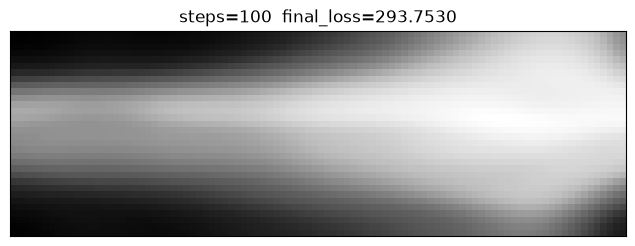

In [6]:
design, loss, trained_model = run_for_steps(steps_w.value)

fig, ax = plt.subplots(figsize=(8, 8 * problem.height / problem.width))
ax.imshow(design, cmap="Greys")
ax.set_title(f"steps={steps_w.value}  final_loss={loss:.4f}")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## Compare multiple step counts side by side

Add/edit values in `step_counts_to_compare` (each 0-400) and run the cell to train one fresh model per value and show the resulting designs in a row, so you can see how the topology changes as training progresses.

Training steps=0 ...
Training steps=50 ...
Training steps=100 ...
Training steps=200 ...
Training steps=400 ...


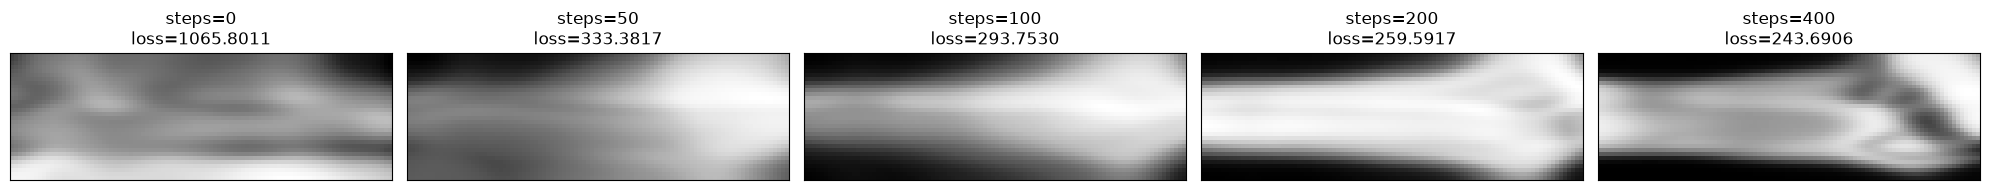

In [7]:
step_counts_to_compare = [0, 50, 100, 200, 400]

results = []
for n in step_counts_to_compare:
    assert 0 <= n <= 400, "each step count must be between 0 and 400"
    print(f"Training steps={n} ...")
    design, loss, _ = run_for_steps(n)
    results.append((n, design, loss))

fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4 * problem.height / problem.width + 1))
if len(results) == 1:
    axes = [axes]
for ax, (n, design, loss) in zip(axes, results):
    ax.imshow(design, cmap="Greys")
    ax.set_title(f"steps={n}\nloss={loss:.4f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## Paper-style B-spline network diagram

Draws the trained KAN exactly like Figure (b) of the KAN paper: **node dots**
connected by lines, with each edge showing its own small plot of the learned
activation function phi(x) (learnable activation functions on *edges*, sum
operation on *nodes*). Each mini plot is labeled with its layer and
from-node -> to-node indices, e.g. `L0: 1->3` = layer 0, input node 1 to
output node 3.

**Sanity limit: at most 20 spline functions.** The single-run cell above must
have been run with a small enough `kan_layers` (e.g. `4` gives
2x4 + 4x1 = 12 edges); with the default `16,16` (304 edges) the cell below
refuses to draw and tells you what to change.

Set the axis limits below — every mini plot uses the same x and y range, so
equal ranges (e.g. -10..10 for both) give square plots and the curves are
directly comparable across edges. Note the splines are only *learned* on
their knot interval (x in [-1, 1] by default); outside it the B-spline bases
are zero and only the SiLU base-activation term remains, so wide x ranges
show extrapolation behavior.

In [8]:
plot_x_min_w = widgets.FloatText(value=-1.0, description="x min:")
plot_x_max_w = widgets.FloatText(value=1.0, description="x max:")
plot_y_min_w = widgets.FloatText(value=-2.0, description="y min:")
plot_y_max_w = widgets.FloatText(value=2.0, description="y max:")
display(plot_x_min_w, plot_x_max_w, plot_y_min_w, plot_y_max_w)

FloatText(value=-1.0, description='x min:')

FloatText(value=1.0, description='x max:')

FloatText(value=-2.0, description='y min:')

FloatText(value=2.0, description='y max:')

Trained KAN has 15 spline functions (limit 20).


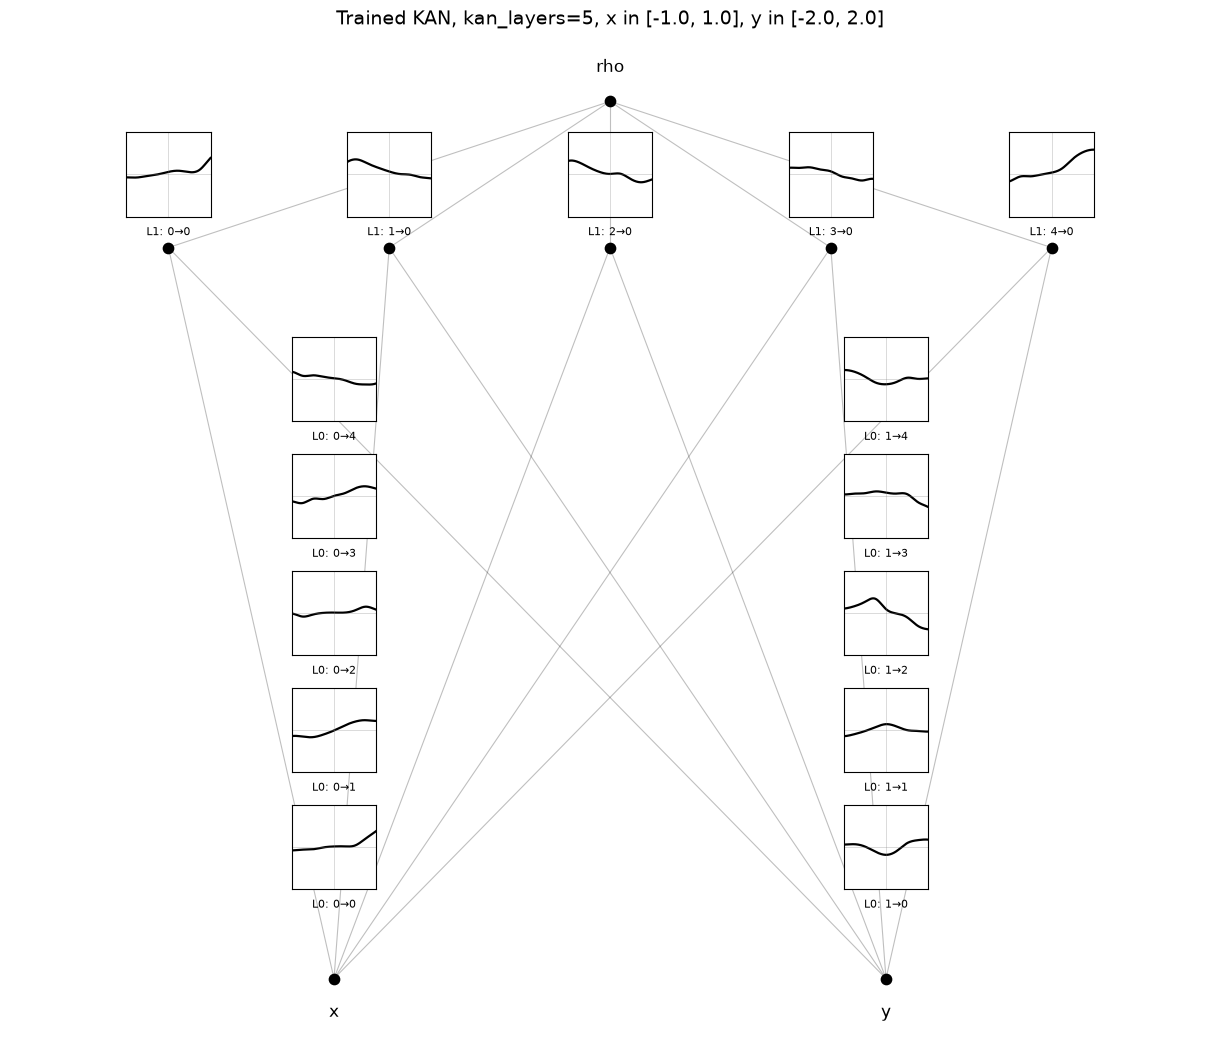

In [9]:
import torch
from matplotlib.lines import Line2D

MAX_SPLINE_PLOTS = 20  # sanity limit


@torch.no_grad()
def edge_function(layer, i, j, x_min, x_max, n_samples=300):
    """Sample the learned activation on edge i->j of one EfficientKANLinear
    layer over [x_min, x_max]: phi(x) = base_weight*SiLU(x) + spline(x).
    Outside the knot interval the B-spline bases are zero, so only the
    SiLU base term remains (extrapolation region)."""
    x = torch.linspace(x_min, x_max, n_samples)
    x_in = torch.zeros(n_samples, layer.in_features)
    x_in[:, i] = x
    bases = layer.b_splines(x_in)  # (n_samples, in_features, n_bases)
    spline_y = torch.einsum('bn,n->b', bases[:, i, :], layer.spline_weight[j, i, :])
    base_y = layer.base_activation(x) * layer.base_weight[j, i]
    return x.numpy(), (base_y + spline_y).numpy()


def plot_kan_diagram(kan, x_range, y_range, in_vars=None, out_vars=None, title=None):
    """Paper-style KAN diagram: node dots + connecting lines + one square
    mini plot per edge showing the learned B-spline activation, each labeled
    with layer and from->to node indices."""
    layers = list(kan.layers)
    widths = [layers[0].in_features] + [l.out_features for l in layers]
    n_edges = sum(l.in_features * l.out_features for l in layers)
    if n_edges > MAX_SPLINE_PLOTS:
        print(f"Refusing to draw: this KAN has {n_edges} spline functions "
              f"(> sanity limit of {MAX_SPLINE_PLOTS}).")
        print(f"Set 'kan_layers' in the hyperparameters above to something small "
              f"(e.g. '4' -> {2*4 + 4*1} edges) and re-run the single-run training cell.")
        return None

    depth = len(layers)
    max_width = max(widths)
    # Every layer's band holds n_out rows of plots; give each band vertical
    # space proportional to its row count so all mini plots end up the same
    # size regardless of layer widths (the paper's uniform look).
    rows_per_band = [l.out_features for l in layers]
    total_rows = sum(rows_per_band)
    fig_w = 2.4 * max_width
    fig_h = 1.5 * total_rows + 1.2
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)

    y_top, y_bot = 0.93, 0.07
    x_left, x_right = 0.04, 0.96

    def node_x(n_nodes, k):
        return x_left + (x_right - x_left) * (k + 0.5) / n_nodes

    node_positions = [[node_x(n, k) for k in range(n)] for n in widths]
    node_y = [y_bot]
    for rows in rows_per_band:
        node_y.append(node_y[-1] + (y_top - y_bot) * rows / total_rows)

    # Uniform square box size across all layers (physical inches), limited by
    # the tightest cell in either dimension anywhere in the network.
    side_in = float("inf")
    for l, layer in enumerate(layers):
        cell_w = (x_right - x_left) / layer.in_features
        band_h = (node_y[l + 1] - node_y[l]) * 0.80
        cell_h = band_h / layer.out_features
        side_in = min(side_in, cell_w * 0.80 * fig_w, cell_h * 0.72 * fig_h)

    for l, layer in enumerate(layers):
        n_in, n_out = layer.in_features, layer.out_features
        y_in, y_out = node_y[l], node_y[l + 1]

        # Tile this layer's edge plots on a grid inside the band between the
        # two node rows: columns = source node i, rows = target node j.
        band_height = y_out - y_in
        band_lo = y_in + band_height * 0.10
        band_hi = y_out - band_height * 0.10
        cell_w = (x_right - x_left) / n_in
        cell_h = (band_hi - band_lo) / n_out
        plot_w = side_in / fig_w
        plot_h = side_in / fig_h

        for i in range(n_in):
            for j in range(n_out):
                x_edge, y_edge = edge_function(layer, i, j, x_range[0], x_range[1])

                x0, x1 = node_positions[l][i], node_positions[l + 1][j]
                ax.add_line(Line2D([x0, x1], [y_in, y_out], color="black",
                                    alpha=0.25, lw=0.8, zorder=1,
                                    transform=fig.transFigure))

                xm = x_left + cell_w * (i + 0.5)
                ym = band_lo + cell_h * (j + 0.5)
                inset = fig.add_axes([xm - plot_w / 2, ym - plot_h / 2, plot_w, plot_h])
                inset.plot(x_edge, y_edge, color="black", lw=1.6)
                inset.set_xlim(x_range)
                inset.set_ylim(y_range)
                inset.axhline(0, color="gray", lw=0.4, alpha=0.5)
                inset.axvline(0, color="gray", lw=0.4, alpha=0.5)
                inset.set_xticks([])
                inset.set_yticks([])
                inset.patch.set_facecolor("white")
                inset.set_zorder(2)

                # Edge info: layer, from-node -> to-node
                inset.text(0.5, -0.12, f"L{l}: {i}" + "\u2192" + f"{j}",
                            transform=inset.transAxes, ha="center", va="top",
                            fontsize=8)

        for i in range(n_in):
            ax.scatter(node_positions[l][i], y_in, s=55, color="black",
                       zorder=3, transform=fig.transFigure)
    for j in range(widths[-1]):
        ax.scatter(node_positions[-1][j], node_y[-1], s=55, color="black",
                   zorder=3, transform=fig.transFigure)

    if in_vars:
        for i, name in enumerate(in_vars):
            ax.text(node_positions[0][i], node_y[0] - 0.025, name,
                    ha="center", va="top", fontsize=12, transform=fig.transFigure)
    if out_vars:
        for j, name in enumerate(out_vars):
            ax.text(node_positions[-1][j], node_y[-1] + 0.025, name,
                    ha="center", va="bottom", fontsize=12, transform=fig.transFigure)
    return fig


x_range = (plot_x_min_w.value, plot_x_max_w.value)
y_range = (plot_y_min_w.value, plot_y_max_w.value)

n_edges = sum(l.in_features * l.out_features for l in trained_model.kan.layers)
print(f"Trained KAN has {n_edges} spline functions (limit {MAX_SPLINE_PLOTS}).")
fig = plot_kan_diagram(
    trained_model.kan, x_range, y_range,
    in_vars=["x", "y"], out_vars=["rho"],
    title=f"Trained KAN, kan_layers={kan_layers_w.value}, "
          f"x in {list(x_range)}, y in {list(y_range)}",
)
if fig is not None:
    plt.show()